<a href="https://colab.research.google.com/github/zo-ff/pandas/blob/main/Exercise_Grouping_and_Sorting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

# 1. 画面に表示されているトークンをここに貼り付ける
os.environ['KAGGLE_USER'] = 'Takehkit'  # user
os.environ['KAGGLE_KEY'] = 'KGAT_cf8367738ad9cc51c218a1993a53c054'  # 画像の長い文字列をここにコピペ

# 2. ワインデータを直接ダウンロードする命令
!pip install kaggle --upgrade  # 念のため最新版に
!kaggle datasets download -d zynicide/wine-reviews
!unzip wine-reviews.zip  # winemag-data-130k-v2.csv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.5/128.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.7/228.7 kB 7.3 MB/s eta 0:00:00
  Attempting uninstall: kagglesdk
    Found existing installation: kagglesdk 0.1.23
    Uninstalling kagglesdk-0.1.23:
      Successfully uninstalled kagglesdk-0.1.23
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2
Dataset URL: https://www.kaggle.com/datasets/zynicide/wine-reviews
License(s): CC-BY-NC-SA-4.0
100% 50.9M/50.9M [00:00<00:00, 204MB/s]

Archive:  wine-reviews.zip
  inflating: winemag-data-130k-v2.csv  
  inflating: winemag-data-130k-v2.json  
  inflating: winemag-data_first150k.csv  


In [4]:
import pandas as pd

reviews = pd.read_csv("/content/winemag-data-130k-v2.csv", index_col=0)
#pd.set_option("display.max_rows", 5)

What combination of countries and varieties are most common? Create a Series whose index is a MultiIndexof {country, variety} pairs. For example, a pinot noir produced in the US should map to {"US", "Pinot Noir"}. Sort the values in the Series in descending order based on wine count.

In [7]:
rev=reviews.value_counts(['country', 'variety'],normalize=True*100)
#country_variety_counts = ____
rev

country    variety                 
US         Pinot Noir                  0.076093
           Cabernet Sauvignon          0.056310
           Chardonnay                  0.052353
France     Bordeaux-style Red Blend    0.036372
Italy      Red Blend                   0.027897
                                         ...   
Argentina  Cabernet-Malbec             0.000008
US         Tinta Madeira               0.000008
Italy      Centesimino                 0.000008
           Catalanesca                 0.000008
           Carmenère                   0.000008
Name: proportion, Length: 1612, dtype: float64

<Axes: >

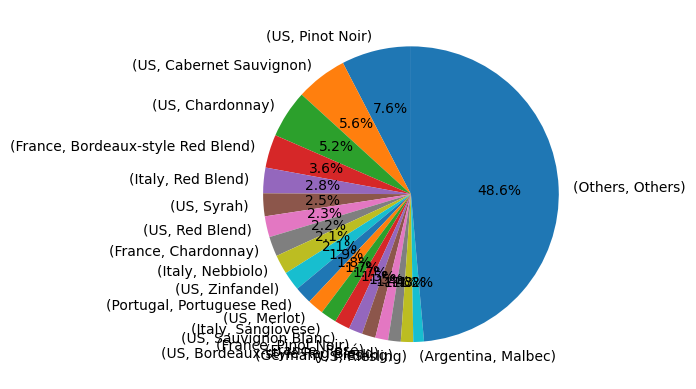

In [8]:
# 1. すべてのカウント結果を取得
counts = reviews.value_counts(['country', 'variety'])

# 2. 上位20個を抜き出す
top20 = counts.head(20)

# 3. 21位以下のデータをすべて足し算して「Others」という名前で Series を作る
others = pd.Series([counts.iloc[20:].sum()], index=[('Others', 'Others')])

# 4. 上位20とOthersを合体させる
plot_data = pd.concat([top20, others])

# 5. 円グラフを描画する（％表記も自動で入れる）
plot_data.plot(kind='pie', autopct='%1.1f%%', startangle=90)

In [ ]:
# ① 上位20個だけを合計すると、全体の何％になる？
reviews.value_counts(['country', 'variety'], normalize=True).head(20).sum()

これを実行すると、例えば 0.35（＝35%）のような数字がポロッと1つだけ返ってきます。

これが出たら、頭の中で 100% - 35% = 65% と引き算をします。

脳内での解釈: 「あ、上位20個を全部合わせても、世界全体の35%にしかならないんだ。ということは、残りの65%は画面に映りきらない1,500以上の雑多なワイン（Others）が占めているんだな」